## Tensorflow Image Classifier

<i>

<br>

### Summary:

This notebook uses `tensorflow` to classify the images of cardboard cutouts which have different figures on them:

* bear
* fox
* reindeer
* santa
* cyclist
* robot

This exercises satisfies Module 3, part 1 of the Cloud-Based Machine Learning course. 

The model itself uses `MobileNetV2` as the backbone and uses the `ImageNet` pre-trained weights. It uses only a single classifier layer (because of the lack of pictures I placed into it.)

<br>
<br>

This notebook was ran using my WindowsPC using a WSL Ubuntu (22.04) instance running on `tensorflow`.

<br>
<br>

<strong> 

Total pictures used for the model: 

`428` </strong>.jpg images

<br>

### Results:

|Accuracy & Loss|Test vs. Validation Accuracy Lineplot|Confusion Matrix|
|---|---|---|
| 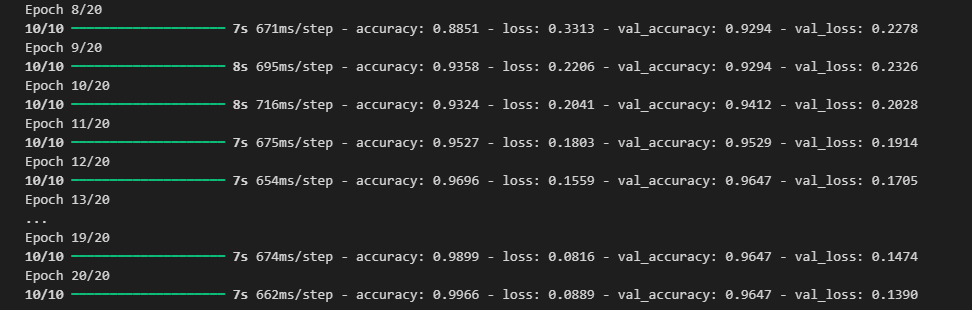 |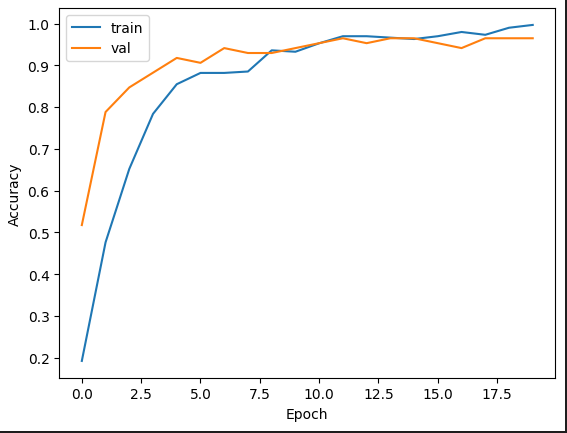    | 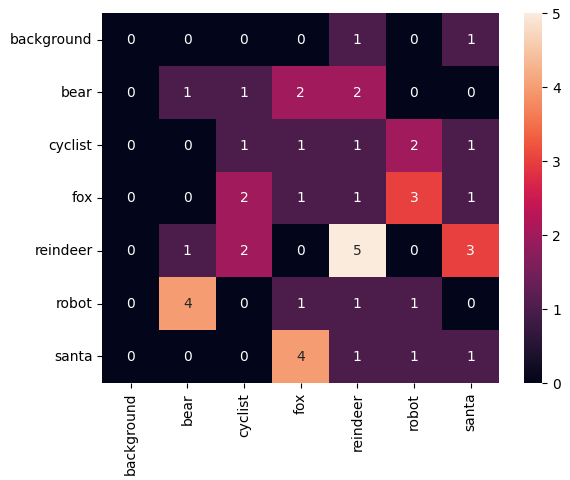  |

<br>
<br>

---

## Code:




#### Imports

In [ ]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

# Ignore warnings
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

2026-03-04 17:44:39.536350: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 17:44:40.570417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:44:44.658362: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


#### Loading Datasets

<i>

Let's start by we defining the three dataset splits: train, test, and validation.

 We set the image_size to 224 because `MobileNetV2` expects it in that form. 


<strong><h5> Note: </strong></h5> 

These images have already been shuffled in the notebook: 04_img_shuffler.ipynb.

In [2]:
# Loading Datasets

# Train Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard_images/train",
image_size = (224,224),
batch_size = 32
)

# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard_images/test",
    image_size = (224,224),
    batch_size = 32
)

# Validation Dataset 
valid_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard_images/val",
    image_size = (224,224),
    batch_size = 32, 
)

Found 296 files belonging to 7 classes.
Found 47 files belonging to 7 classes.
Found 85 files belonging to 7 classes.


E0000 00:00:1772639088.141465   53216 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772639088.172414   53216 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


#### Data Augmentation

<i>

Data Augmentation here is useful since we only have a limited amount of images to work with.
I've kept it fairly simple and not terribly aggressive. I might consider playing around with this later.

In [3]:
'''
This part replates the images and alters them slightly.

It does the following: 

* Randomly flips them in a direction
* Rotates the images randomly
* Zooms in and out a little randomly
* Gives different contrasts at random intensities

We call this later when we define the model. 
'''

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])


#### Compiling

<i>

Here is where we trained the dataset. I added a lot of comments and notes, mostly for myself because all of this is rather new.


In [4]:
'''
This section uses the MobileNetV2 backbone. We chose this because it's lightweight and
not overly complex, which reduces the chance of overfitting.

- input_shape = (224, 224). Why? Because MobileNetV2 expects it.

- include_top = False. Why? Because by default, MobileNetV2 expects 1000 ImageNet Classes.
                In our case, we put our own trained classifier on top, while using their 
                backbone and pre-trained weights.

- weights='imagenet'. Why? Because we're transfer learning. It uses 14 million images already.
                that helps figure out some basic patterns already. 
'''

# Pretrained backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

'''
base_model.trainable = False. What does this mean?

It freezes all the imagenet's pretrained weights on TOP of our
classifier. Handy! (We could experiment with this a little later)
'''
base_model.trainable = False 


'''
Most of this is familiar to use, but there's some exceptions:
tf.keras.layers.Dropout(0.5): Why? Seems a bit aggressive.

Since we have a small dataset, we need to be aggressive anyways to reduce features, or
it will overfit. Additionally, we already have some pre-trained weights so we can afford to do that.. maybe!
'''
# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(9, activation='softmax')
])


'''
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), why? 

Here, we're using adam for adaptive learning, and it works very well out of the box. Different optimizers 
have different compatible learning rates. 0.001 made sure it didn't overfit. We could probably get away with 
a little more, but I've spent 10 hours on optimization already. I have to move on. 
'''
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Giving a summary of the dimensionality.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Training and Crossvalidation

<i> 

Here, we train the model and check for overfitting with the validation accuracy metric. We're mostly interested in a high `val_accuracy` metric here.

In [5]:
# Fitting the model to the validation dataset, to check for overfitting.
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 858ms/step - accuracy: 0.1926 - loss: 2.4727 - val_accuracy: 0.5176 - val_loss: 1.3744
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 797ms/step - accuracy: 0.4764 - loss: 1.4607 - val_accuracy: 0.7882 - val_loss: 0.8320
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 800ms/step - accuracy: 0.6520 - loss: 0.9098 - val_accuracy: 0.8471 - val_loss: 0.5724
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 767ms/step - accuracy: 0.7838 - loss: 0.6625 - val_accuracy: 0.8824 - val_loss: 0.4373
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 777ms/step - accuracy: 0.8547 - loss: 0.4672 - val_accuracy: 0.9176 - val_loss: 0.3348
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 788ms/step - accuracy: 0.8818 - loss: 0.3763 - val_accuracy: 0.9059 - val_loss: 0.3027
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 694ms/step - accuracy: 0.8818 - loss: 0.3818 - val_accuracy: 0.9412 - val_loss: 0.2475
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 671ms/step - accuracy: 0.8851 - loss: 0.3313 - val_accuracy: 0

---

### Visualizing the train vs. validation accuracy.

<i>

And to show our work, lets add a  visual that shows the model's accuracy for:

* training dataset
* validation dataset 

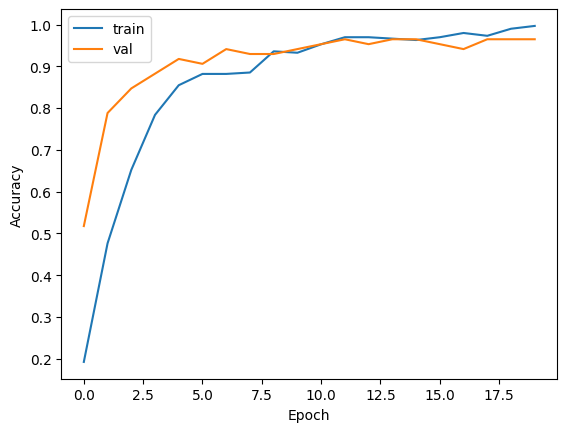

In [ ]:
# Showing the train vs validation plot (snippet taken from instructor and modified)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Setting up for Confusion Matrix

<i> Below, we start to setup so see can determine which predictions were incorrect.


To do that,  we need to begin by turning the predicted and actual values as numpy arrays first.

In [ ]:
# Let's figure out what predictions were given first.
# We do this by predicting the test dataset an finding the highest number (confidence interval) in the list
# called np.argmax. 

# In other words, find the highest confidence interval in the list, that's the prediction. Drop everything else.-
predictions = model.predict(test_ds)
predictions = np.argmax(predictions, axis=1)
predictions


# Now we need to extract labels.
y_labels = []

# We call images first --> then labels to unpack the images in test_ds.
for images, labels in test_ds:
    # Then we extend (which adds multiple elements to a list. Our batch size is 32, so it gives 32 elements at minimum.)
    y_labels.extend(labels.numpy())

# Then we convert y_labels into a numpy array.
y_true = np.array(y_labels)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 789ms/step


2026-03-04 17:47:29.859933: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Confusion Matrix Visual

<i>

From here, we simply create the confusion matrix using `seaborn` (faster, simpler.)

['background', 'bear', 'cyclist', 'fox', 'reindeer', 'robot', 'santa']


<Axes: >

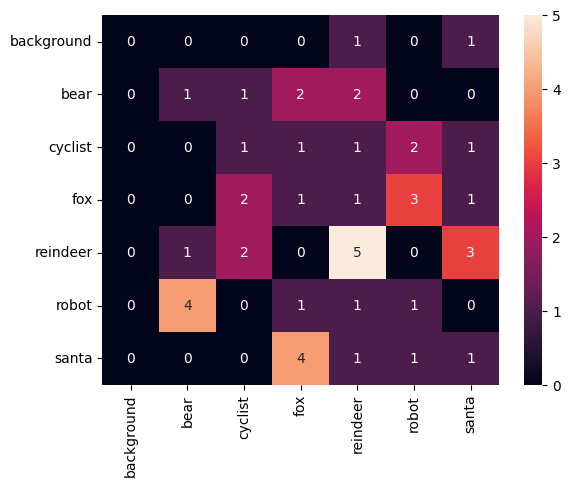

In [ ]:
# First, let's store the class_names.
class_names = test_ds.class_names
print(class_names)

# Second, we write a confusion matrix based on the 
# the true values and the predictions
cm = confusion_matrix(y_true, predictions)

# Finally, create the heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names
)